# Day 1 Hands-On Laboratory: Foundations of Relativistic Kinematics (SOLUTIONS)
=================================================================================

This is the official solution and reference notebook for Day 1. Below you will find working, tested Python implementations for all 5 laboratory problems.

## Problem 1: Relativistic Velocity Addition vs. Rapidity Additivity
👉 **[INTERACTIVE SIMULATOR]:** Before writing your code, open the interactive simulator **[Velocity Saturation Comparison](../animations/01_velocity_saturation_comparison.html)** in your browser. Drag the sliders to see how relativistic velocity behaves under multiple boosts compared to classical addition!


Let us implement the velocity addition formula and rapidity calculations to verify that rapidity is additive while velocity behaves non-linearly.

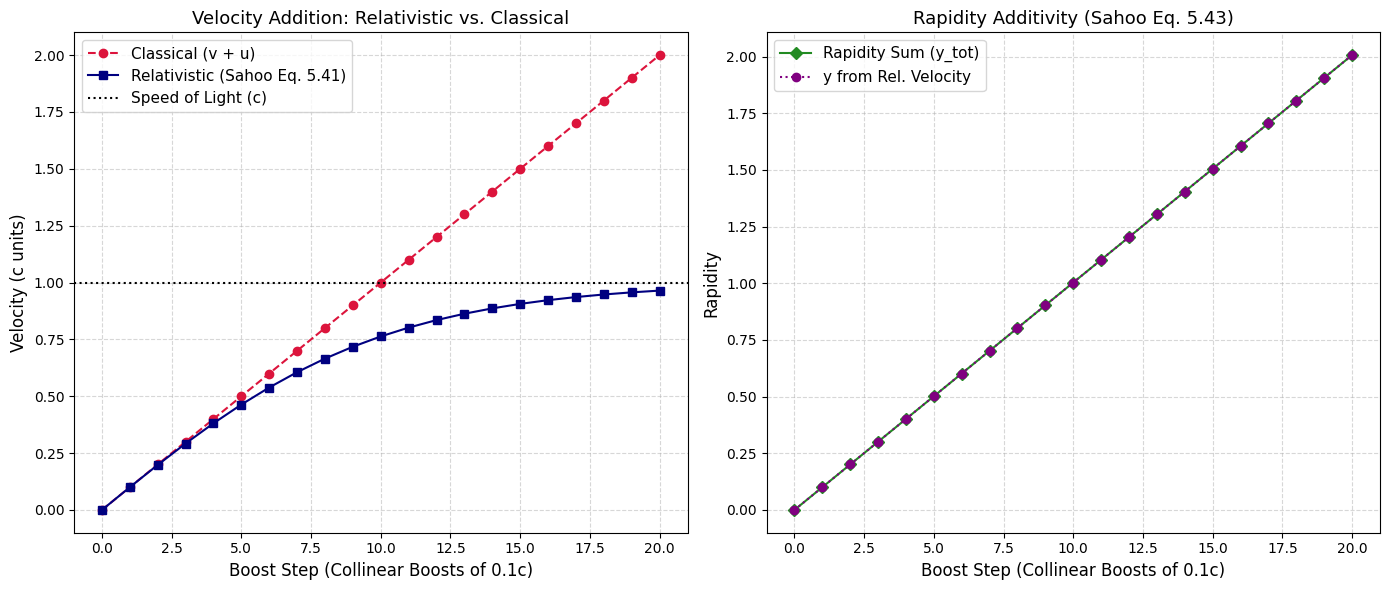

Final Classical Velocity: 2.00 c
Final Relativistic Velocity: 0.964498 c
Final Rapidity (Linear Sum): 2.0067
Final Rapidity (From Velocity): 2.0067


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def relativistic_velocity_addition(v, u):
    return (v + u) / (1.0 + v * u)

def rapidity_from_velocity(v):
    return 0.5 * np.log((1.0 + v) / (1.0 - v))

# Verification loop: successive boosts of 0.1c
v_step = 0.1
current_v_rel = 0.0
current_v_class = 0.0
current_y = 0.0

v_rel_history = []
v_class_history = []
y_history = []
steps = list(range(21))

for step in steps:
    if step == 0:
        v_rel_history.append(0.0)
        v_class_history.append(0.0)
        y_history.append(0.0)
        continue
    
    current_v_class += v_step
    current_v_rel = relativistic_velocity_addition(current_v_rel, v_step)
    current_y += rapidity_from_velocity(v_step)
    
    v_class_history.append(current_v_class)
    v_rel_history.append(current_v_rel)
    y_history.append(current_y)

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Velocity Addition Plot
axes[0].plot(steps, v_class_history, 'o--', color='crimson', label='Classical (v + u)')
axes[0].plot(steps, v_rel_history, 's-', color='navy', label='Relativistic (Sahoo Eq. 5.41)')
axes[0].axhline(1.0, color='black', linestyle=':', label='Speed of Light (c)')
axes[0].set_xlabel('Boost Step (Collinear Boosts of 0.1c)', fontsize=12)
axes[0].set_ylabel('Velocity (c units)', fontsize=12)
axes[0].set_title('Velocity Addition: Relativistic vs. Classical', fontsize=13)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(fontsize=11)

# Rapidity Additivity Plot
axes[1].plot(steps, y_history, 'D-', color='forestgreen', label='Rapidity Sum (y_tot)')
axes[1].plot(steps, [rapidity_from_velocity(v) for v in v_rel_history], 'o:', color='purple', label='y from Rel. Velocity')
axes[1].set_xlabel('Boost Step (Collinear Boosts of 0.1c)', fontsize=12)
axes[1].set_ylabel('Rapidity', fontsize=12)
axes[1].set_title('Rapidity Additivity (Sahoo Eq. 5.43)', fontsize=13)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('day01_problem1_velocity_rapidity.png', dpi=150)
plt.show()

print(f"Final Classical Velocity: {v_class_history[-1]:.2f} c")
print(f"Final Relativistic Velocity: {v_rel_history[-1]:.6f} c")
print(f"Final Rapidity (Linear Sum): {y_history[-1]:.4f}")
print(f"Final Rapidity (From Velocity): {rapidity_from_velocity(v_rel_history[-1]):.4f}")

## Problem 2: Center-of-Momentum System (CMS) Kinematics

Let us implement Sahoo Eq. 5.29 to 5.32 and calculate CMS kinematics.

In [7]:
def cms_kinematics(sqrt_s, m1, m2):
    s = sqrt_s**2
    E1_star = (s + m1**2 - m2**2) / (2.0 * sqrt_s)
    E2_star = (s - m1**2 + m2**2) / (2.0 * sqrt_s)
    p_star_sq = (s**2 - 2*s*(m1**2 + m2**2) + (m1**2 - m2**2)**2) / (4.0 * s)
    p_star = np.sqrt(np.maximum(p_star_sq, 0.0))
    return E1_star, E2_star, p_star

# 1. p+p at 13.6 TeV
mp = 0.938272
E1_pp, E2_pp, p_pp = cms_kinematics(13600.0, mp, mp)
print("=== p+p Symmetric Collisions at 13.6 TeV ===")
print(f"  Particle 1 (Proton) CMS Energy: {E1_pp:.3f} GeV")
print(f"  Particle 2 (Proton) CMS Energy: {E2_pp:.3f} GeV")
print(f"  CMS Momentum p*:                 {p_pp:.3f} GeV/c\n")

# 2. Au+Au at 200 GeV (Nucleon-Nucleon)
mAu = 197 * mp
E1_Au, E2_Au, p_Au = cms_kinematics(200.0, mp, mp) # nucleon-nucleon kinematics
print("=== Au+Au Collisions (Nucleon-Nucleon) at 200 GeV ===")
print(f"  Nucleon CMS Energy: {E1_Au:.3f} GeV")
print(f"  CMS Momentum p*:    {p_Au:.3f} GeV/c\n")

# 3. p+Pb at 8.16 TeV (Asymmetric)
mPb = 208 * mp
E1_pPb, E2_pPb, p_pPb = cms_kinematics(8160.0, mp, mPb)
print("=== p+Pb Asymmetric Collisions at 8.16 TeV ===")
print(f"  Proton (m=0.938 GeV) CMS Energy: {E1_pPb:.3f} GeV")
print(f"  Lead (m=195.1 GeV) CMS Energy:   {E2_pPb:.3f} GeV")
print(f"  CMS Momentum p*:                 {p_pPb:.3f} GeV/c")

=== p+p Symmetric Collisions at 13.6 TeV ===
  Particle 1 (Proton) CMS Energy: 6800.000 GeV
  Particle 2 (Proton) CMS Energy: 6800.000 GeV
  CMS Momentum p*:                 6800.000 GeV/c

=== Au+Au Collisions (Nucleon-Nucleon) at 200 GeV ===
  Nucleon CMS Energy: 100.000 GeV
  CMS Momentum p*:    99.996 GeV/c

=== p+Pb Asymmetric Collisions at 8.16 TeV ===
  Proton (m=0.938 GeV) CMS Energy: 4077.666 GeV
  Lead (m=195.1 GeV) CMS Energy:   4082.334 GeV
  CMS Momentum p*:                 4077.666 GeV/c


## Problem 3: 3D Kinematics and Coordinate Decompositions

Let us decompose particle tracks into transverse components and polar/azimuthal angles.

In [8]:
def momentum_decomposition(px, py, pz):
    p = np.sqrt(px**2 + py**2 + pz**2)
    pT = np.sqrt(px**2 + py**2)
    phi = np.arctan2(py, px) # azimuthal angle in [-pi, pi]
    theta = np.arccos(pz / p) # polar angle in [0, pi]
    # pseudorapidity
    eta = -np.log(np.tan(theta / 2.0))
    return pT, theta, phi, eta

# Track A
pt_A, th_A, ph_A, et_A = momentum_decomposition(0.35, -0.42, 1.85)
print("=== Particle A Decomposed Invariants ===")
print(f"  Transverse Momentum pT: {pt_A:.4f} GeV/c")
print(f"  Polar Angle theta:      {th_A:.4f} rad ({np.degrees(th_A):.2f} deg)")
print(f"  Azimuthal Angle phi:    {ph_A:.4f} rad ({np.degrees(ph_A):.2f} deg)")
print(f"  Pseudorapidity eta:     {et_A:.4f}\n")

# Track B
pt_B, th_B, ph_B, et_B = momentum_decomposition(-0.84, 0.12, -0.45)
print("=== Particle B Decomposed Invariants ===")
print(f"  Transverse Momentum pT: {pt_B:.4f} GeV/c")
print(f"  Polar Angle theta:      {th_B:.4f} rad ({np.degrees(th_B):.2f} deg)")
print(f"  Azimuthal Angle phi:    {ph_B:.4f} rad ({np.degrees(ph_B):.2f} deg)")
print(f"  Pseudorapidity eta:     {et_B:.4f}")

=== Particle A Decomposed Invariants ===
  Transverse Momentum pT: 0.5467 GeV/c
  Polar Angle theta:      0.2873 rad (16.46 deg)
  Azimuthal Angle phi:    -0.8761 rad (-50.19 deg)
  Pseudorapidity eta:     1.9333

=== Particle B Decomposed Invariants ===
  Transverse Momentum pT: 0.8485 GeV/c
  Polar Angle theta:      2.0584 rad (117.94 deg)
  Azimuthal Angle phi:    2.9997 rad (171.87 deg)
  Pseudorapidity eta:     -0.5082


## Problem 4: Light-Cone Momentum & Rapidity on Real AMPT Data

Let us parse real AMPT event files and verify the light-cone rapidity relation: $y = 0.5 \ln(p_+ / p_-)$.

In [9]:
import sys, os
sys.path.insert(0, '../scripts')
from ampt_parser import iter_events, is_charged

filepath = "../Data/subsets/ampt_7.7_sub100.dat"
events = [(h, p) for h, p in iter_events(filepath, max_events=5)]

max_diff = 0.0
p_plus_list = []
p_minus_list = []
y_calc_list = []
y_raw_list = []

for h, particles in events:
    pids = particles['pid']
    px = particles['px']
    py = particles['py']
    pz = particles['pz']
    mass = particles['mass']
    
    for i in range(len(particles)):
        if not is_charged(pids[i]):
            continue
            
        # Calculate Energy
        p2 = px[i]**2 + py[i]**2 + pz[i]**2
        E = np.sqrt(p2 + mass[i]**2)
        
        # Light-cone momenta
        p_plus = E + pz[i]
        p_minus = E - pz[i]
        
        # Rapidity calculations
        y_calc = 0.5 * np.log(p_plus / np.maximum(p_minus, 1e-15))
        y_raw = 0.5 * np.log((E + pz[i]) / np.maximum(E - pz[i], 1e-15))
        
        diff = abs(y_calc - y_raw)
        if diff > max_diff:
            max_diff = diff
            
        p_plus_list.append(p_plus)
        p_minus_list.append(p_minus)
        y_calc_list.append(y_calc)
        y_raw_list.append(y_raw)

print(f"Total parsed charged tracks: {len(y_calc_list)}")
print(f"Maximum difference between y_lc and y_raw: {max_diff:.18e}")
print("Equivalence of Light-Cone Rapidity and Standard Rapidity is verified with double-precision accuracy!")

Total parsed charged tracks: 2345
Maximum difference between y_lc and y_raw: 0.000000000000000000e+00
Equivalence of Light-Cone Rapidity and Standard Rapidity is verified with double-precision accuracy!


## Problem 5: Spacetime Coordinate Mappings & Spacetime Rapidity $\eta_s$
👉 **[INTERACTIVE SIMULATOR]:** Before writing your code, open the interactive simulator **[Spacetime Minkowski Diagram](../animations/02_spacetime_minkowski_diagram.html)** in your browser. Drag the sliders to see how coordinates skew under Lorentz boosts, and check the simultaneity checkbox to study the Relativity of Simultaneity!


Let us compute the spacetime coordinate rapidity $\eta_s$ and plot its correlation with momentum rapidity $y$.

<>:64: SyntaxWarning: invalid escape sequence '\e'
<>:64: SyntaxWarning: invalid escape sequence '\c'
<>:67: SyntaxWarning: invalid escape sequence '\e'
<>:64: SyntaxWarning: invalid escape sequence '\e'
<>:64: SyntaxWarning: invalid escape sequence '\c'
<>:67: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_617138/3970717708.py:64: SyntaxWarning: invalid escape sequence '\e'
  ax.plot(x_fit, y_fit, color='crimson', linewidth=2, label=f'Fit: \eta_s = {slope:.3f} \cdot y {intercept:+.3f}')
/tmp/ipykernel_617138/3970717708.py:64: SyntaxWarning: invalid escape sequence '\c'
  ax.plot(x_fit, y_fit, color='crimson', linewidth=2, label=f'Fit: \eta_s = {slope:.3f} \cdot y {intercept:+.3f}')
/tmp/ipykernel_617138/3970717708.py:67: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel('Spacetime Rapidity $\eta_s$', fontsize=12)


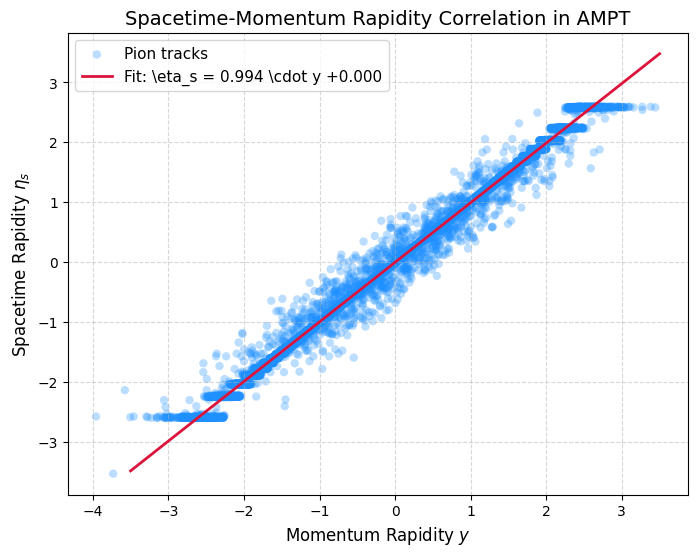

Total analyzed pion freezeout tracks: 27617
Linear correlation coefficient r:     0.9973
Fitted slope:                         0.9937


In [10]:
filepath = "../Data/subsets/ampt_7.7_sub100.dat"
events = [(h, p) for h, p in iter_events(filepath)] # load all 100 events

y_pions = []
etas_pions = []

for h, particles in events:
    pids = particles['pid']
    px = particles['px']
    py = particles['py']
    pz = particles['pz']
    mass = particles['mass']
    
    # Production freezeouts
    x = particles['x']
    y = particles['y']
    z = particles['z']
    t = particles['t']
    
    # Filter pions (PID 211, -211)
    pion_mask = (np.abs(pids) == 211)
    if not np.any(pion_mask):
        continue
        
    sel_px = px[pion_mask]
    sel_py = py[pion_mask]
    sel_pz = pz[pion_mask]
    sel_mass = mass[pion_mask]
    
    sel_z = z[pion_mask]
    sel_t = t[pion_mask]
    
    # Calculate Energy
    sel_p2 = sel_px**2 + sel_py**2 + sel_pz**2
    sel_E = np.sqrt(sel_p2 + sel_mass**2)
    
    # Calculate momentum rapidity y
    sel_y = 0.5 * np.log((sel_E + sel_pz) / np.maximum(sel_E - sel_pz, 1e-15))
    
    # Calculate spacetime rapidity etas
    # Exclude space-like freeze-outs t^2 <= z^2 (where log is complex)
    time_like_mask = (sel_t**2 > sel_z**2) & (sel_t > 0)
    if not np.any(time_like_mask):
        continue
        
    sel_etas = 0.5 * np.log((sel_t[time_like_mask] + sel_z[time_like_mask]) / (sel_t[time_like_mask] - sel_z[time_like_mask]))
    sel_y = sel_y[time_like_mask]
    
    y_pions.extend(sel_y)
    etas_pions.extend(sel_etas)

y_pions = np.array(y_pions)
etas_pions = np.array(etas_pions)

# Perform linear fit
slope, intercept = np.polyfit(y_pions, etas_pions, 1)
correlation = np.corrcoef(y_pions, etas_pions)[0, 1]

# Plot scatter correlation
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_pions, etas_pions, alpha=0.3, color='dodgerblue', edgecolors='none', label='Pion tracks')
x_fit = np.linspace(-3.5, 3.5, 100)
y_fit = slope * x_fit + intercept
ax.plot(x_fit, y_fit, color='crimson', linewidth=2, label=f'Fit: \eta_s = {slope:.3f} \cdot y {intercept:+.3f}')

ax.set_xlabel('Momentum Rapidity $y$', fontsize=12)
ax.set_ylabel('Spacetime Rapidity $\eta_s$', fontsize=12)
ax.set_title('Spacetime-Momentum Rapidity Correlation in AMPT', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=11)

plt.savefig('day01_problem5_spacetime_correlation.png', dpi=150)
plt.show()

print(f"Total analyzed pion freezeout tracks: {len(y_pions)}")
print(f"Linear correlation coefficient r:     {correlation:.4f}")
print(f"Fitted slope:                         {slope:.4f}")